# Credit Card Fraud Detection

## Part 01 — Data Audit & Class Imbalance Baseline

## Project Goal

This project focuses on detecting fraudulent credit card transactions in a highly imbalanced dataset.

Only a very small number of transactions are fraudulent, so accuracy alone is not a good measure of model performance. The project will compare different ways of handling class imbalance, evaluate models using fraud-focused metrics, and tune the final decision threshold based on business costs.

## Part 01

The first step is to understand the dataset and the class imbalance before building any machine learning models.

This includes:

- checking the structure and quality of the data
- looking at the distribution of legitimate and fraudulent transactions
- calculating the fraud rate
- creating a naive baseline
- understanding why accuracy is misleading for this problem
- introducing the metrics that will be used later

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import precision_score, recall_score, f1_score

## Load the Dataset

In [2]:
df = pd.read_csv("../data/raw/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Dataset Overview

The dataset contains credit card transactions with anonymized numerical features.

The `Class` column is the target variable:

- `0` = legitimate transaction
- `1` = fraudulent transaction

The `V1` to `V28` columns are anonymized transaction features. Their individual business meanings are not provided in the dataset.

`Time` represents the time elapsed between transactions, while `Amount` represents the transaction amount.

## Initial Data Inspection

In [3]:
df.shape

(284807, 31)

In [4]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [5]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

### Missing Values

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df.duplicated().sum()

np.int64(1081)

## Fraud Class Distribution

The main problem in this dataset is the severe imbalance between legitimate and fraudulent transactions.

The `Class` column is the target that we are trying to predict.

In [8]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [9]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [10]:
df["Class"].value_counts(normalize=True).mul(100).round(2)

Class
0    99.83
1     0.17
Name: proportion, dtype: float64

### Class Imbalance Finding

There are 284,315 legitimate transactions and only 492 fraudulent transactions.

Fraudulent transactions make up approximately 0.17% of the dataset, while legitimate transactions make up approximately 99.83%.

This is a severe class imbalance. A model could achieve very high accuracy by predicting almost every transaction as legitimate while still missing most or all fraudulent transactions.

## Visualizing the Class Imbalance

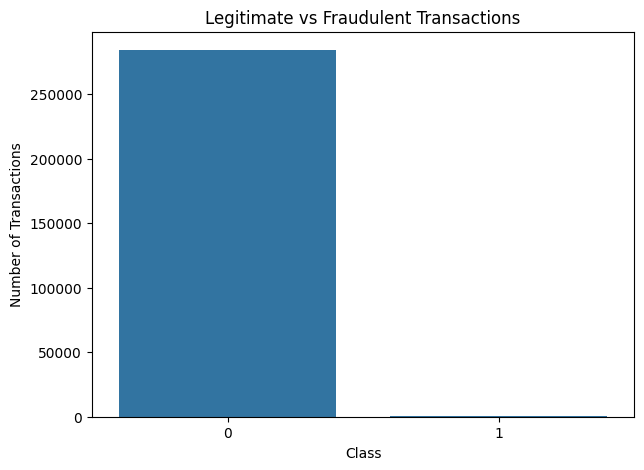

In [11]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)

plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.savefig("../images/1_class_distribution.png")
plt.show()

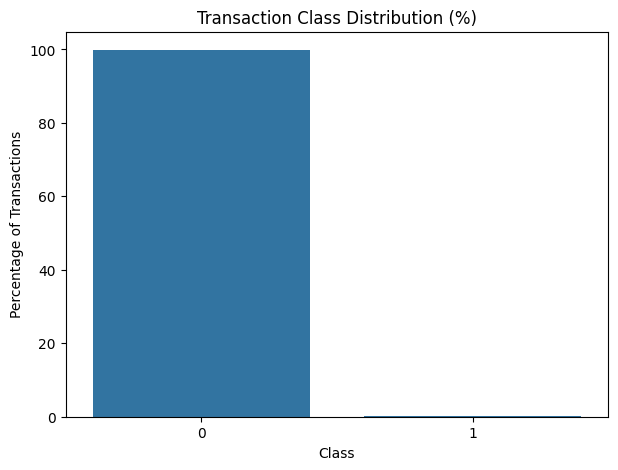

In [12]:
class_percentages = df["Class"].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))
sns.barplot(x=class_percentages.index, y=class_percentages.values)

plt.title("Transaction Class Distribution (%)")
plt.xlabel("Class")
plt.ylabel("Percentage of Transactions")
plt.savefig("../images/2_class_distribution_percentage.png")
plt.show()

## Naive Baseline

Before building a machine learning model, it is useful to create a very simple baseline.

Because legitimate transactions make up almost the entire dataset, we can create a naive classifier that predicts every transaction as legitimate.

This baseline is intentionally simple. Its purpose is to show why accuracy can be misleading when the target classes are highly imbalanced.

In [13]:
baseline_predictions = np.zeros(len(df), dtype=int)
baseline_accuracy = (baseline_predictions == df["Class"]).mean()
baseline_accuracy

np.float64(0.9982725143693799)

In [14]:
baseline_accuracy * 100

np.float64(99.82725143693798)

### Baseline Fraud Metrics

In [15]:
baseline_precision = precision_score(
    df["Class"],
    baseline_predictions,
    zero_division=0
)

baseline_recall = recall_score(
    df["Class"],
    baseline_predictions,
    zero_division=0
)

baseline_f1 = f1_score(
    df["Class"],
    baseline_predictions,
    zero_division=0
)

baseline_precision, baseline_recall, baseline_f1

(0.0, 0.0, 0.0)

The naive baseline has 0 precision, 0 recall and 0 F1-score for the fraud class because it does not predict any transactions as fraudulent.

This makes the limitation of accuracy even clearer. Although the baseline achieves approximately 99.83% accuracy, it completely fails to identify fraud.

### Why Accuracy Is Misleading

The naive baseline achieves approximately 99.83% accuracy by predicting every transaction as legitimate.

However, this model detects no fraudulent transactions at all.

This shows that accuracy is not enough for this problem. A fraud detection model must be evaluated based on how well it identifies the rare fraudulent transactions, not just how many predictions it gets correct overall.

## Evaluation Metrics

Because fraud is the positive class, the main metrics need to focus on how well the model identifies fraudulent transactions.

### Precision

Precision answers:

"Of the transactions predicted as fraud, how many were actually fraud?"

A high precision means the model does not generate too many false fraud alerts.

### Recall

Recall answers:

"Of all the actual fraudulent transactions, how many did the model find?"

A high recall means fewer fraudulent transactions are missed.

### F1-score

F1-score combines precision and recall into a single metric.

It is useful when both false positives and false negatives matter.

### ROC-AUC

ROC-AUC measures how well the model separates the two classes across different classification thresholds.

### PR-AUC

PR-AUC summarizes the relationship between precision and recall across different thresholds.

For this project, PR-AUC is especially useful because the fraud class is extremely rare.

## False Positives and False Negatives

In fraud detection, there are two important types of mistakes.

A false positive happens when a legitimate transaction is incorrectly flagged as fraud.

A false negative happens when a fraudulent transaction is incorrectly classified as legitimate.

Both matter, but they have different business consequences. Missing a fraudulent transaction can result in financial loss, while incorrectly blocking a legitimate transaction can create a poor customer experience.

The later stages of the project will use this trade-off when choosing the final classification threshold.

## Class Distribution Summary

In [16]:
class_summary = pd.DataFrame({
    "Transaction Type": ["Legitimate", "Fraud"],
    "Count": [
        (df["Class"] == 0).sum(),
        (df["Class"] == 1).sum()
    ],
    "Percentage": [
        (df["Class"] == 0).mean() * 100,
        (df["Class"] == 1).mean() * 100
    ]
})

class_summary

,Transaction Type,Count,Percentage
0,Legitimate,284315,99.827251
1,Fraud,492,0.172749


In [17]:
class_summary["Percentage"] = class_summary["Percentage"].round(2)
class_summary

,Transaction Type,Count,Percentage
0,Legitimate,284315,99.83
1,Fraud,492,0.17


## Part 01 Findings

The dataset contains 284,807 transactions across 31 columns.

There are 284,315 legitimate transactions and 492 fraudulent transactions. Fraud represents only 0.17% of all transactions.

The class distribution is therefore highly imbalanced.

A naive model that predicts every transaction as legitimate achieves approximately 99.83% accuracy but detects zero fraudulent transactions. This confirms that accuracy alone would give a misleading view of model performance.

For the rest of the project, precision, recall, F1-score, ROC-AUC, and PR-AUC will provide a more useful way to evaluate fraud detection models.

# Part 02 — Leakage-Safe Preprocessing & Pipeline Setup

### Goal

The next step is to prepare the data for machine learning without allowing information from the test set to influence the training process.

The features and target will be separated first, followed by a stratified train/test split. A preprocessing pipeline will then be created so that transformations are fitted only on training data.

An imbalanced-learn pipeline will also be introduced so that future resampling methods can be applied only during model training and cross-validation.

## Separate Features and Target

In [18]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [19]:
X.shape, y.shape

((284807, 30), (284807,))

The target column `Class` has been separated from the transaction features.

There are 30 input features and 284,807 target values.

## Train-Test Split

The data will be divided into training and test sets using an 80/20 split.

Stratification is used so that the very small fraud class remains represented in both sets at approximately the same rate.

The test set will be kept separate from preprocessing, resampling, and model training.

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [22]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((227845, 30), (56962, 30), (227845,), (56962,))

### Checking the Class Distribution After the Split

In [23]:
y_train.value_counts()

Class
0    227451
1       394
Name: count, dtype: int64

In [24]:
y_test.value_counts()

Class
0    56864
1       98
Name: count, dtype: int64

In [25]:
y_train.value_counts(normalize=True) * 100

Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64

In [26]:
y_test.value_counts(normalize=True) * 100

Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64

### Split Check

The stratified split keeps the class distribution approximately the same in both the training and test sets.

The fraud class remains around 0.17% in both sets.

The test set will now be kept untouched while preprocessing, resampling, and model training are performed using the training data.

## Preprocessing Pipeline

The preprocessing step will be placed inside a pipeline instead of being applied manually to the full dataset.

This means the scaler will learn its values from the training data when the pipeline is fitted. The test data will only be transformed using the values learned from training data.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

preprocessing_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

In [28]:
preprocessing_pipeline

,steps,"[('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True


In [29]:
preprocessing_pipeline.fit(X_train)

,steps,"[('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True


In [30]:
X_train_scaled = preprocessing_pipeline.transform(X_train)
X_test_scaled = preprocessing_pipeline.transform(X_test)

In [31]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

## Imbalanced-Learn Pipeline

An imbalanced-learn pipeline allows preprocessing, resampling, and a model to be treated as one workflow.

The important part is that the resampling step will only be performed when the pipeline is fitted on training data.

This prevents the test set from being resampled and helps prevent leakage during cross-validation.

In [32]:
imbalance_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("sampler", RandomUnderSampler(random_state=42))
])

## Why the Pipeline Matters

Resampling should never be performed on the full dataset before cross-validation.

For example, applying SMOTE to the entire dataset before creating training and validation folds could allow synthetic examples to contain information derived from observations that later appear in the validation fold.

The imbalanced-learn pipeline avoids this by applying the resampling step only when the training portion of each fold is fitted.

The test set remains completely untouched until final model evaluation.

# Part 03 — Imbalance Strategy Comparison

## Goal

The fraud class is extremely rare, so the model needs a way to handle the class imbalance.

Three strategies will be compared using the same Logistic Regression model:

- class weighting
- random undersampling
- SMOTE oversampling

The comparison will use precision, recall, F1-score, ROC-AUC and PR-AUC.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

## Baseline Model

Logistic Regression will be used for this comparison.

Using the same model for all three strategies makes it easier to see the effect of the imbalance-handling method itself.

The goal of this stage is not to find the best possible model yet. That will be handled in the later model comparison and tuning stages.

## Cross-Validation

The three strategies will be compared using stratified 5-fold cross-validation on the training data.

The test set will remain untouched until the final evaluation stage.

Stratification is used because the fraud class is very small.

In [34]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Evaluation Metrics

Each strategy will be evaluated using five metrics.

Precision measures how many transactions predicted as fraud are actually fraudulent.

Recall measures how many of the actual fraudulent transactions are detected.

F1-score combines precision and recall.

ROC-AUC measures how well the model separates the two classes across thresholds.

PR-AUC is especially useful for this problem because the fraud class is extremely rare.

In [35]:
scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

### 1. Class Weighting

In [36]:
class_weight_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

### 2. Random Undersampling

In [37]:
undersampling_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("sampler", RandomUnderSampler(random_state=42)),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

### 3. SMOTE Oversampling

In [38]:
smote_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("sampler", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

## Why the Resampling Is Safe

The resampling methods are inside the imbalanced-learn pipelines.

This means that during cross-validation, each resampling method is applied only to the training portion of each fold.

The validation portion is not resampled.

The separate test set is also not resampled.

This prevents information from the validation or test data from leaking into model training.

In [39]:
class_weight_results = cross_validate(
    class_weight_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)
class_weight_results

{'fit_time': array([1.35630178, 1.30317259, 1.24112439, 1.46541405, 1.42232704]),
 'score_time': array([0.07510042, 0.06770563, 0.07184887, 0.05763125, 0.06241202]),
 'test_precision': array([0.06053068, 0.06635945, 0.06686047, 0.05723125, 0.06299213]),
 'test_recall': array([0.93589744, 0.91139241, 0.87341772, 0.93670886, 0.91139241]),
 'test_f1': array([0.11370717, 0.12371134, 0.12421242, 0.10787172, 0.11783961]),
 'test_roc_auc': array([0.99263619, 0.98091694, 0.96802914, 0.99504189, 0.97579577]),
 'test_pr_auc': array([0.8166403 , 0.75839613, 0.67411864, 0.80626469, 0.73026067])}

In [40]:
class_weight_summary = {
    "Strategy": "Class Weighting",
    "Precision": class_weight_results["test_precision"].mean(),
    "Recall": class_weight_results["test_recall"].mean(),
    "F1": class_weight_results["test_f1"].mean(),
    "ROC-AUC": class_weight_results["test_roc_auc"].mean(),
    "PR-AUC": class_weight_results["test_pr_auc"].mean()
}

class_weight_summary

{'Strategy': 'Class Weighting',
 'Precision': np.float64(0.06279479264101687),
 'Recall': np.float64(0.9137617656604998),
 'F1': np.float64(0.1174684507750543),
 'ROC-AUC': np.float64(0.9824839842147348),
 'PR-AUC': np.float64(0.7571360842475147)}

In [41]:
class_weight_results["test_precision"].std()

np.float64(0.00361537441246607)

In [42]:
undersampling_results = cross_validate(
    undersampling_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [43]:
undersampling_summary = {
    "Strategy": "Random Undersampling",
    "Precision": undersampling_results["test_precision"].mean(),
    "Recall": undersampling_results["test_recall"].mean(),
    "F1": undersampling_results["test_f1"].mean(),
    "ROC-AUC": undersampling_results["test_roc_auc"].mean(),
    "PR-AUC": undersampling_results["test_pr_auc"].mean()
}

undersampling_summary

{'Strategy': 'Random Undersampling',
 'Precision': np.float64(0.036864700424215815),
 'Recall': np.float64(0.9163258682246024),
 'F1': np.float64(0.07082009831974043),
 'ROC-AUC': np.float64(0.9818096425597304),
 'PR-AUC': np.float64(0.6622638264704233)}

In [44]:
smote_results = cross_validate(
    smote_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [45]:
smote_summary = {
    "Strategy": "SMOTE",
    "Precision": smote_results["test_precision"].mean(),
    "Recall": smote_results["test_recall"].mean(),
    "F1": smote_results["test_f1"].mean(),
    "ROC-AUC": smote_results["test_roc_auc"].mean(),
    "PR-AUC": smote_results["test_pr_auc"].mean()
}

smote_summary

{'Strategy': 'SMOTE',
 'Precision': np.float64(0.05812636474895437),
 'Recall': np.float64(0.9188250567997404),
 'F1': np.float64(0.10930628267514975),
 'ROC-AUC': np.float64(0.9805452998769372),
 'PR-AUC': np.float64(0.7527513433898763)}

## Strategy Comparison

In [46]:
comparison = pd.DataFrame([
    class_weight_summary,
    undersampling_summary,
    smote_summary
])

comparison.round(4)

,Strategy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Class Weighting,0.0628,0.9138,0.1175,0.9825,0.7571
1,Random Undersampling,0.0369,0.9163,0.0708,0.9818,0.6623
2,SMOTE,0.0581,0.9188,0.1093,0.9805,0.7528


In [47]:
comparison_std = pd.DataFrame([
    {
        "Strategy": "Class Weighting",
        "Precision": class_weight_results["test_precision"].std(),
        "Recall": class_weight_results["test_recall"].std(),
        "F1": class_weight_results["test_f1"].std(),
        "ROC-AUC": class_weight_results["test_roc_auc"].std(),
        "PR-AUC": class_weight_results["test_pr_auc"].std()
    },
    {
        "Strategy": "Random Undersampling",
        "Precision": undersampling_results["test_precision"].std(),
        "Recall": undersampling_results["test_recall"].std(),
        "F1": undersampling_results["test_f1"].std(),
        "ROC-AUC": undersampling_results["test_roc_auc"].std(),
        "PR-AUC": undersampling_results["test_pr_auc"].std()
    },
    {
        "Strategy": "SMOTE",
        "Precision": smote_results["test_precision"].std(),
        "Recall": smote_results["test_recall"].std(),
        "F1": smote_results["test_f1"].std(),
        "ROC-AUC": smote_results["test_roc_auc"].std(),
        "PR-AUC": smote_results["test_pr_auc"].std()
    }
])

comparison_std.round(4)

,Strategy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Class Weighting,0.0036,0.0230,0.0062,0.0102,0.0521
1,Random Undersampling,0.0051,0.0271,0.0094,0.0101,0.0485
2,SMOTE,0.0031,0.0219,0.0054,0.0115,0.0483


## Imbalance Strategy Performance

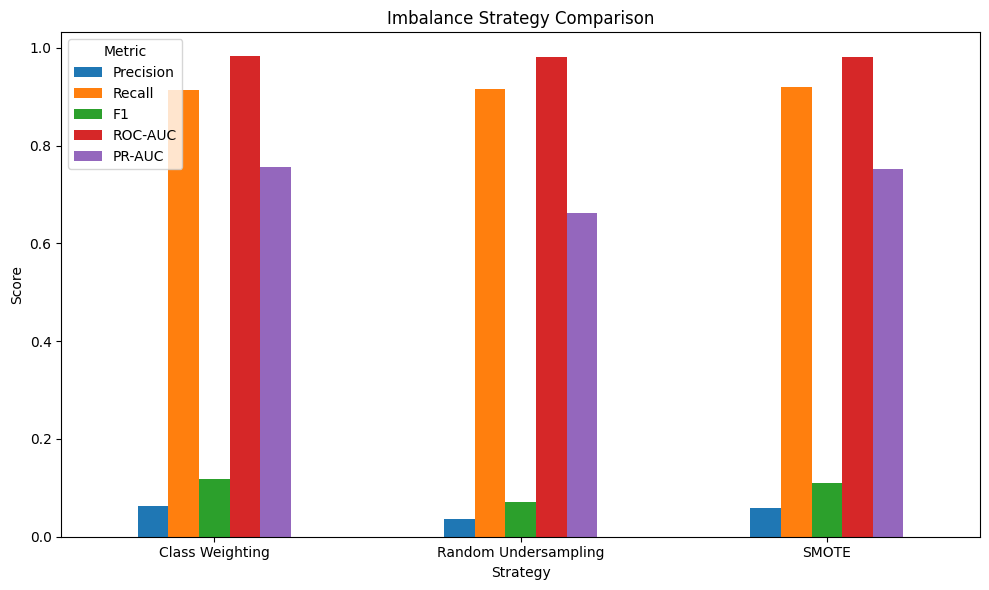

In [48]:
comparison_plot = comparison.set_index("Strategy")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Imbalance Strategy Comparison")
plt.xlabel("Strategy")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.tight_layout()
plt.savefig("../images/3_imbalance_strategy_comparison.png")
plt.show()

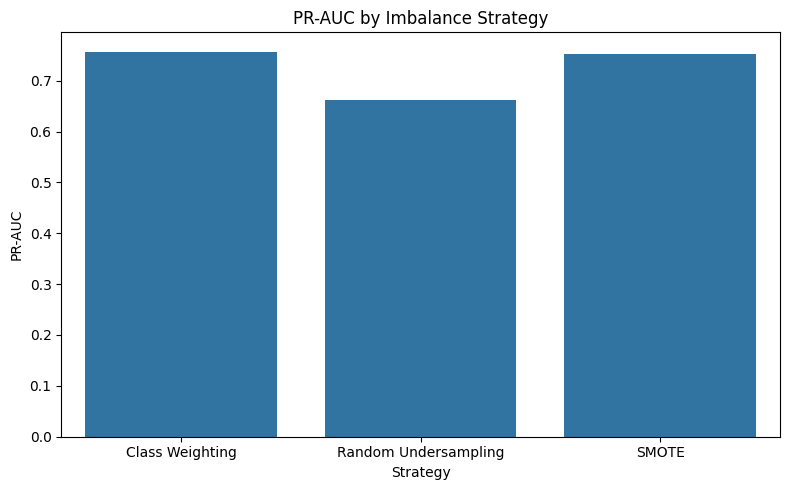

In [49]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Strategy",
    y="PR-AUC"
)

plt.title("PR-AUC by Imbalance Strategy")
plt.xlabel("Strategy")
plt.ylabel("PR-AUC")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("../images/4_pr_auc_by_strategy.png")
plt.show()

## Part 03 Findings

The three imbalance strategies produced different precision, recall, F1-score, ROC-AUC and PR-AUC results.

Class weighting achieved the highest precision (0.0628), F1-score (0.1175), ROC-AUC (0.9825) and PR-AUC (0.7571). Its recall was 0.9138.

Random undersampling achieved a recall of 0.9163, but it had the lowest precision (0.0369), F1-score (0.0708) and PR-AUC (0.6623) of the three strategies.

SMOTE achieved the highest recall at 0.9188. However, its precision (0.0581), F1-score (0.1093), ROC-AUC (0.9805) and PR-AUC (0.7528) were slightly lower than class weighting.

The main trade-off between the strategies was between identifying more fraudulent transactions and limiting false positive predictions.

PR-AUC was given particular attention because fraud represents only a very small proportion of all transactions.

Based on the cross-validation results, class weighting was the strongest overall strategy at this stage because it performed best on precision, F1-score, ROC-AUC and PR-AUC.

# Part 04 — Model Family Comparison

## Goal

The previous stage compared different ways of handling class imbalance using Logistic Regression.

This stage compares two different model families using the strongest imbalance strategy from Part 03: class weighting.

The models will be compared using precision, recall, F1-score, ROC-AUC and PR-AUC.

ROC and precision-recall curves will also be used to compare their ability to separate fraudulent transactions from legitimate ones.

In [50]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

In [51]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

scale_pos_weight

np.float64(577.2868020304569)

In [52]:
logistic_model = ImbPipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

In [53]:
xgb_model = ImbPipeline([
    ("model", XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

In [54]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [55]:
model_scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [56]:
logistic_results = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring=model_scoring,
    n_jobs=-1
)

logistic_results

{'fit_time': array([1.00848746, 1.46707273, 1.31482816, 1.57720733, 1.58341289]),
 'score_time': array([0.04321098, 0.09104967, 0.09947395, 0.0733707 , 0.07618976]),
 'test_precision': array([0.06053068, 0.06635945, 0.06686047, 0.05723125, 0.06299213]),
 'test_recall': array([0.93589744, 0.91139241, 0.87341772, 0.93670886, 0.91139241]),
 'test_f1': array([0.11370717, 0.12371134, 0.12421242, 0.10787172, 0.11783961]),
 'test_roc_auc': array([0.99263619, 0.98091694, 0.96802914, 0.99504189, 0.97579577]),
 'test_pr_auc': array([0.8166403 , 0.75839613, 0.67411864, 0.80626469, 0.73026067])}

In [57]:
logistic_summary = {
    "Model": "Logistic Regression",
    "Precision": logistic_results["test_precision"].mean(),
    "Recall": logistic_results["test_recall"].mean(),
    "F1": logistic_results["test_f1"].mean(),
    "ROC-AUC": logistic_results["test_roc_auc"].mean(),
    "PR-AUC": logistic_results["test_pr_auc"].mean()
}

logistic_summary

{'Model': 'Logistic Regression',
 'Precision': np.float64(0.06279479264101687),
 'Recall': np.float64(0.9137617656604998),
 'F1': np.float64(0.1174684507750543),
 'ROC-AUC': np.float64(0.9824839842147348),
 'PR-AUC': np.float64(0.7571360842475147)}

In [58]:
xgb_results = cross_validate(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring=model_scoring,
    n_jobs=-1
)

xgb_results

{'fit_time': array([9.39176154, 9.5828402 , 9.34376884, 9.41228342, 9.7000339 ]),
 'score_time': array([0.30755711, 0.29957676, 0.30292249, 0.32534814, 0.26142287]),
 'test_precision': array([0.5112782 , 0.56140351, 0.46043165, 0.45283019, 0.52755906]),
 'test_recall': array([0.87179487, 0.81012658, 0.81012658, 0.91139241, 0.84810127]),
 'test_f1': array([0.64454976, 0.66321244, 0.58715596, 0.60504202, 0.65048544]),
 'test_roc_auc': array([0.99547163, 0.97754382, 0.97189339, 0.99503494, 0.98212905]),
 'test_pr_auc': array([0.82294328, 0.80880293, 0.74613272, 0.859527  , 0.77918069])}

In [59]:
xgb_summary = {
    "Model": "XGBoost",
    "Precision": xgb_results["test_precision"].mean(),
    "Recall": xgb_results["test_recall"].mean(),
    "F1": xgb_results["test_f1"].mean(),
    "ROC-AUC": xgb_results["test_roc_auc"].mean(),
    "PR-AUC": xgb_results["test_pr_auc"].mean()
}

xgb_summary

{'Model': 'XGBoost',
 'Precision': np.float64(0.5027005205468532),
 'Recall': np.float64(0.8503083414475819),
 'F1': np.float64(0.630089123053803),
 'ROC-AUC': np.float64(0.9844145664364176),
 'PR-AUC': np.float64(0.8033173241068358)}

In [60]:
model_comparison = pd.DataFrame([
    logistic_summary,
    xgb_summary
])

model_comparison.round(4)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.0628,0.9138,0.1175,0.9825,0.7571
1,XGBoost,0.5027,0.8503,0.6301,0.9844,0.8033


In [61]:
model_comparison_std = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Precision": logistic_results["test_precision"].std(),
        "Recall": logistic_results["test_recall"].std(),
        "F1": logistic_results["test_f1"].std(),
        "ROC-AUC": logistic_results["test_roc_auc"].std(),
        "PR-AUC": logistic_results["test_pr_auc"].std()
    },
    {
        "Model": "XGBoost",
        "Precision": xgb_results["test_precision"].std(),
        "Recall": xgb_results["test_recall"].std(),
        "F1": xgb_results["test_f1"].std(),
        "ROC-AUC": xgb_results["test_roc_auc"].std(),
        "PR-AUC": xgb_results["test_pr_auc"].std()
    }
])

model_comparison_std.round(4)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.0036,0.0230,0.0062,0.0102,0.0521
1,XGBoost,0.0410,0.0385,0.0290,0.0094,0.0385


In [62]:
logistic_probabilities = cross_val_predict(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

xgb_probabilities = cross_val_predict(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

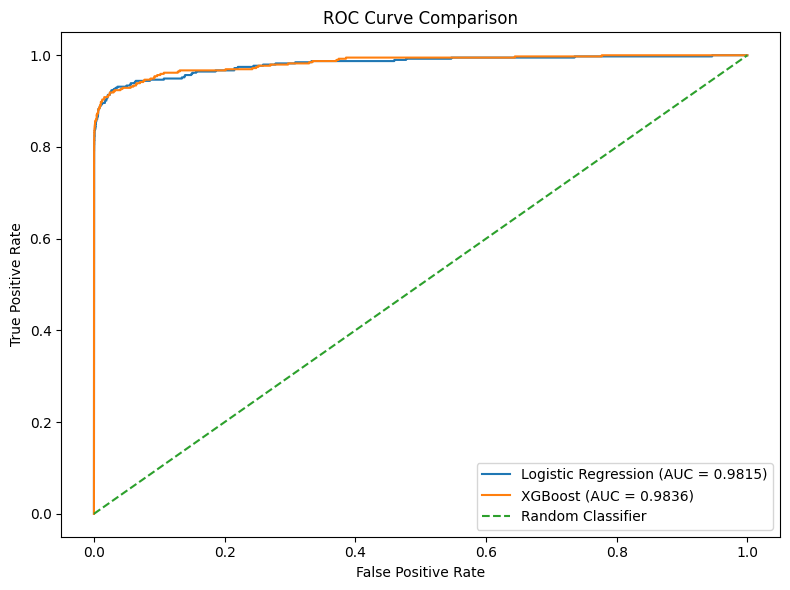

In [63]:
logistic_fpr, logistic_tpr, _ = roc_curve(
    y_train,
    logistic_probabilities
)

xgb_fpr, xgb_tpr, _ = roc_curve(
    y_train,
    xgb_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_train, logistic_probabilities):.4f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC = {roc_auc_score(y_train, xgb_probabilities):.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

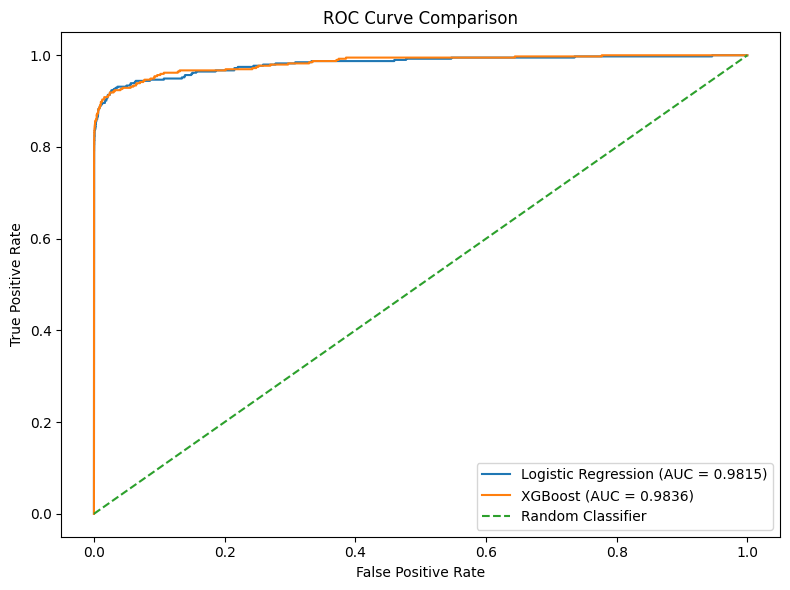

In [64]:
plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_train, logistic_probabilities):.4f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC = {roc_auc_score(y_train, xgb_probabilities):.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../images/5_model_family_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

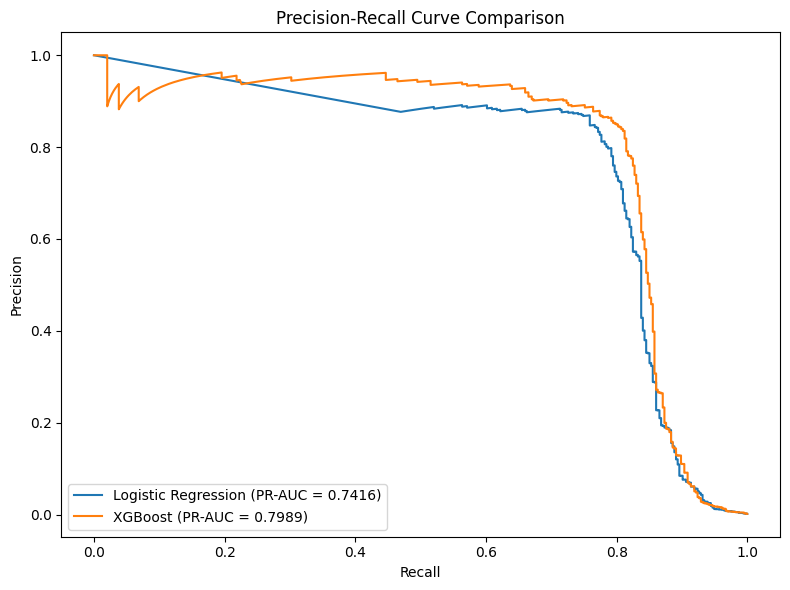

In [65]:
logistic_precision, logistic_recall, _ = precision_recall_curve(
    y_train,
    logistic_probabilities
)

xgb_precision, xgb_recall, _ = precision_recall_curve(
    y_train,
    xgb_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_recall,
    logistic_precision,
    label=f"Logistic Regression (PR-AUC = {average_precision_score(y_train, logistic_probabilities):.4f})"
)

plt.plot(
    xgb_recall,
    xgb_precision,
    label=f"XGBoost (PR-AUC = {average_precision_score(y_train, xgb_probabilities):.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

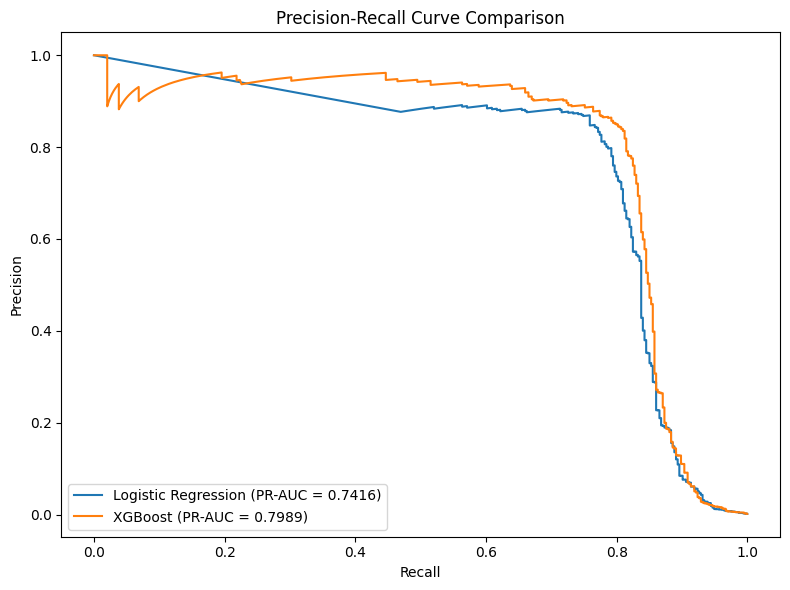

In [66]:
plt.figure(figsize=(8, 6))

plt.plot(
    logistic_recall,
    logistic_precision,
    label=f"Logistic Regression (PR-AUC = {average_precision_score(y_train, logistic_probabilities):.4f})"
)

plt.plot(
    xgb_recall,
    xgb_precision,
    label=f"XGBoost (PR-AUC = {average_precision_score(y_train, xgb_probabilities):.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../images/6_model_family_pr_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

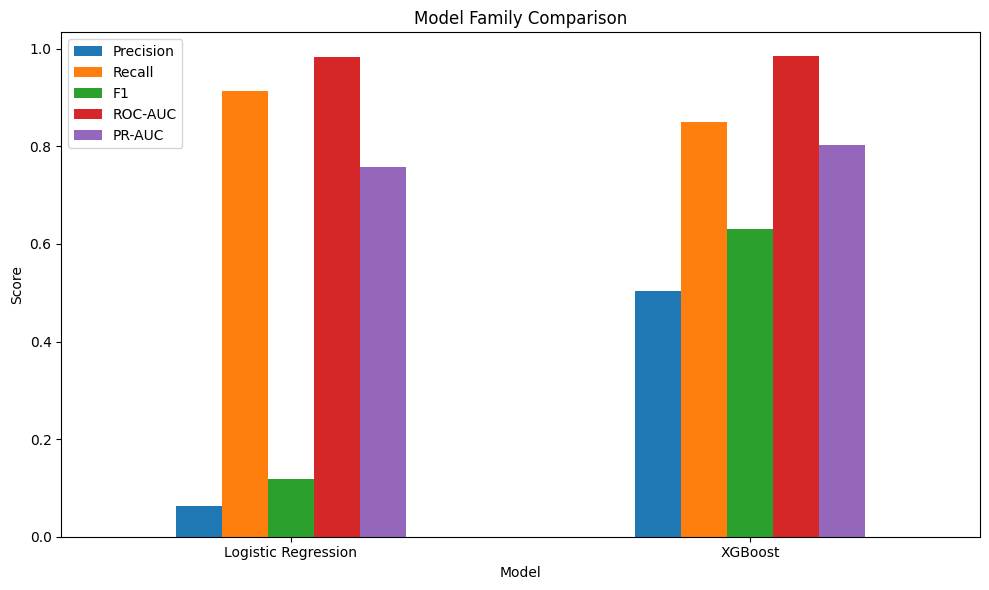

In [67]:
model_comparison_plot = model_comparison.set_index("Model")

model_comparison_plot[
    ["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Family Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()

plt.savefig(
    "../images/7_model_family_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Part 04 Findings

Two different model families were compared: Logistic Regression and XGBoost.

Both models used the class-weighted approach identified as the strongest imbalance strategy in Part 03.

The models were evaluated using stratified 5-fold cross-validation on the training data.

Logistic Regression achieved a PR-AUC of 0.7571, while XGBoost achieved a PR-AUC of 0.8033.

XGBoost achieved much higher precision (0.5027) and F1-score (0.6301) than Logistic Regression, while Logistic Regression achieved higher recall (0.9138) than XGBoost (0.8503).

XGBoost also achieved slightly higher ROC-AUC (0.9844 versus 0.9825) and higher PR-AUC (0.8033 versus 0.7571).

The ROC and precision-recall curves showed stronger overall performance from XGBoost, especially in terms of precision-recall performance.

Based on the cross-validation results, XGBoost was the stronger model family at this stage because it achieved higher precision, F1-score, ROC-AUC and PR-AUC, while still maintaining a high recall.

The test set was not used for model selection and remains untouched for final evaluation.